Mounted at /content/drive
External dataset already extracted.

External dataset:
/content/drive/MyDrive/CSE475_Project/data/external_dataset
buildings : 24 images
forest    : 35 images
glacier   : 32 images
mountain  : 31 images
sea       : 32 images
street    : 46 images

Total external images: 200

Checking model files...
Found: /content/drive/MyDrive/CSE475_Project/saved_models/cnn_basic/baseline_cnn_basic.keras
Found: /content/drive/MyDrive/CSE475_Project/saved_models/cnn_advanced/baseline_cnn_advanced.keras
Found: /content/drive/MyDrive/CSE475_Project/saved_models/efficientnet_basic/efficientnet_b0_basic.keras
Found: /content/drive/MyDrive/CSE475_Project/saved_models/efficientnet_advanced/efficientnet_b0_advanced.keras


EXTERNAL DATASET EVALUATION


----------------------------------------------------------------------
CNN + Basic Augmentation
----------------------------------------------------------------------
Loading model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0

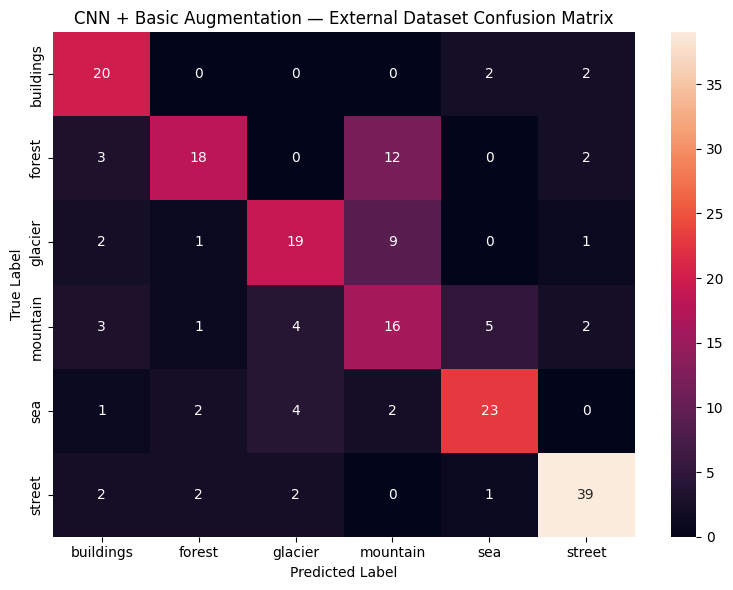

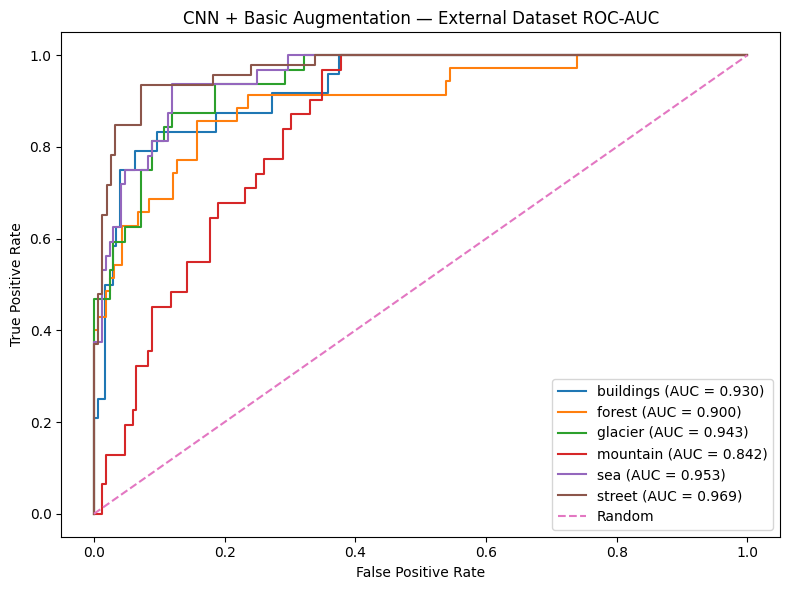



----------------------------------------------------------------------
CNN + Advanced Augmentation
----------------------------------------------------------------------
Loading model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6800 - loss: 1.0048

Results:
Test Loss: 1.0048
Test Accuracy: 0.68
Weighted F1 Score: 0.6684
Weighted ROC-AUC: 0.9236


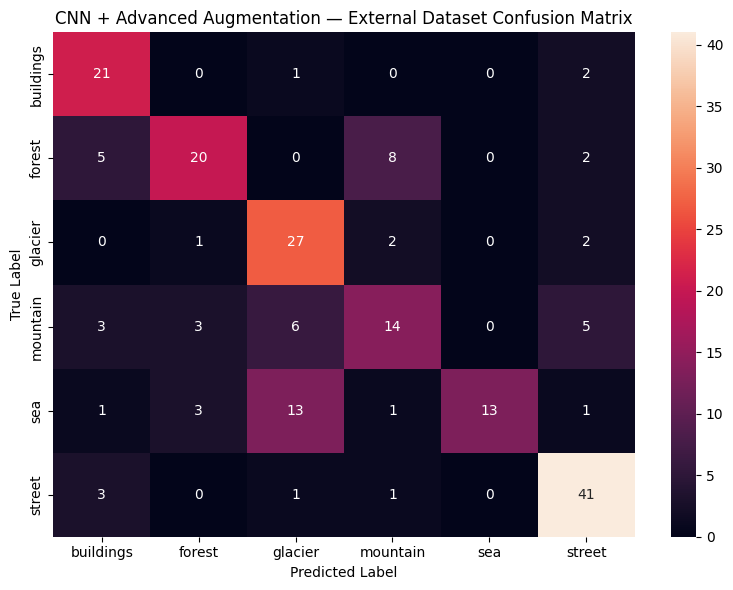

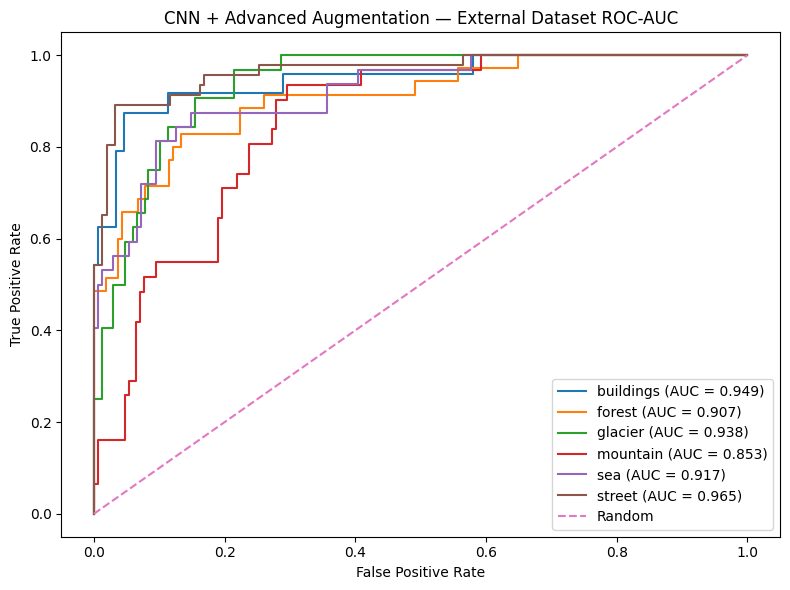



----------------------------------------------------------------------
EfficientNetB0 + Basic Augmentation
----------------------------------------------------------------------
Loading model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.8850 - loss: 0.3011



Results:
Test Loss: 0.3011
Test Accuracy: 0.885
Weighted F1 Score: 0.8874
Weighted ROC-AUC: 0.9892


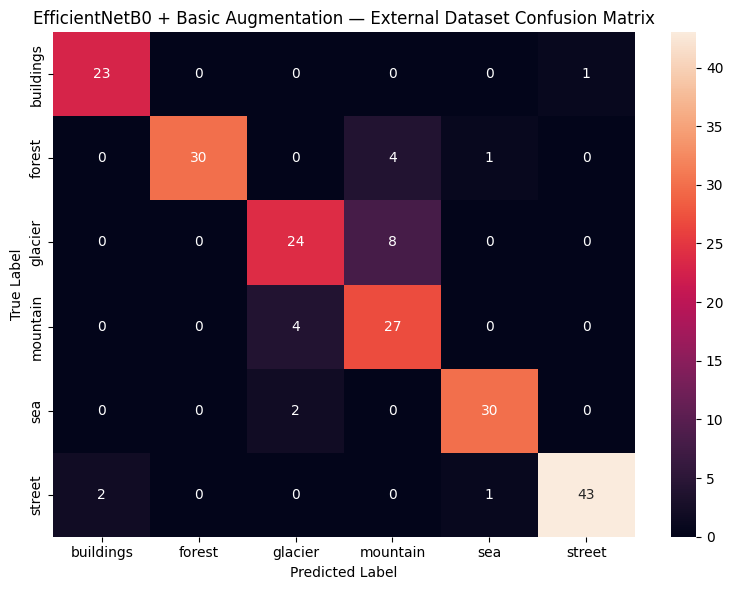

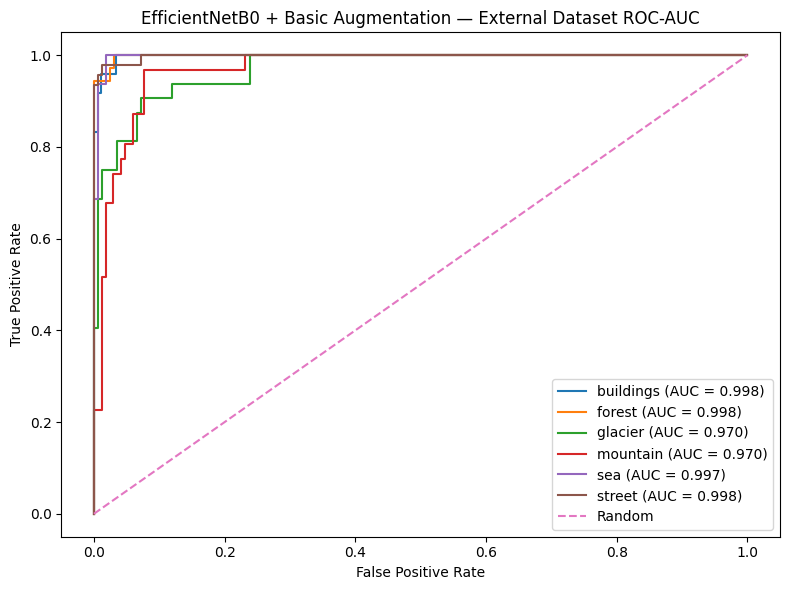



----------------------------------------------------------------------
EfficientNetB0 + Advanced Augmentation
----------------------------------------------------------------------
Loading model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8800 - loss: 0.3256



Results:
Test Loss: 0.3256
Test Accuracy: 0.88
Weighted F1 Score: 0.8813
Weighted ROC-AUC: 0.9873


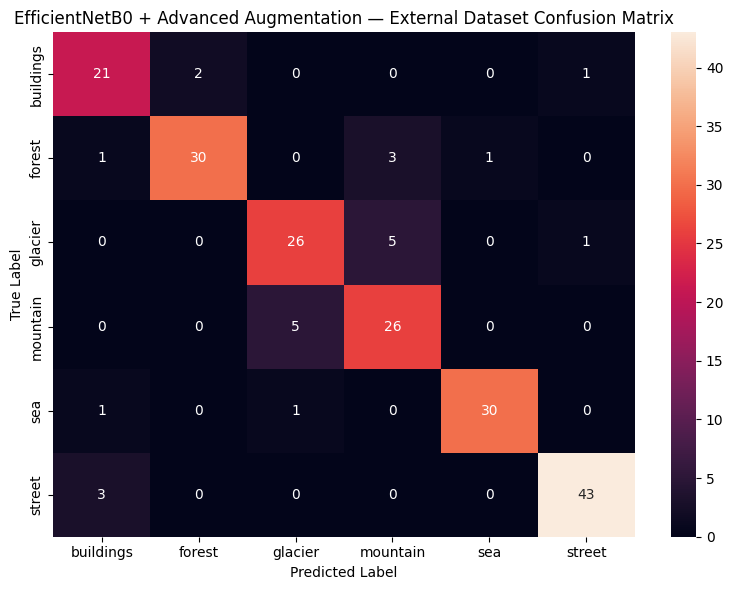

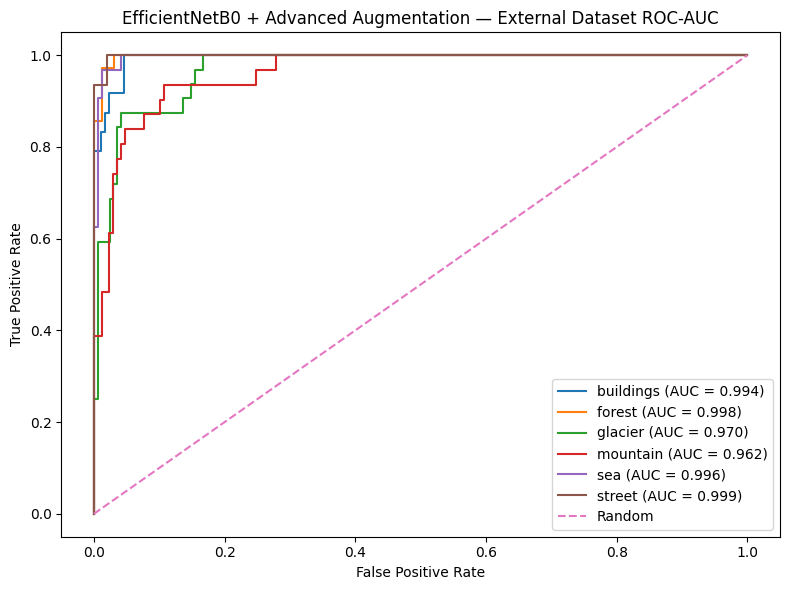



EXTERNAL DATASET METRICS
                                 Model  Test Loss  Test Accuracy  Weighted F1 Score  Weighted ROC-AUC
              CNN + Basic Augmentation   0.951218          0.675           0.676407          0.925951
           CNN + Advanced Augmentation   1.004820          0.680           0.668414          0.923608
   EfficientNetB0 + Basic Augmentation   0.301148          0.885           0.887412          0.989224
EfficientNetB0 + Advanced Augmentation   0.325582          0.880           0.881260          0.987300

Saved metrics:
/content/drive/MyDrive/CSE475_Project/results/external_evaluation/external_dataset_metrics.csv

Saved figures:
/content/drive/MyDrive/CSE475_Project/results/external_evaluation


ALL FOUR MODELS EVALUATED


In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from google.colab import drive


drive.mount("/content/drive")


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/CSE475_Project"
)

DATA_DIR = PROJECT_ROOT / "data"

EXTERNAL_ZIP = (
    DATA_DIR / "external_dataset.zip"
)

EXTERNAL_DIR = (
    DATA_DIR / "external_dataset"
)

MODEL_DIR = (
    PROJECT_ROOT / "saved_models"
)

RESULTS_DIR = (
    PROJECT_ROOT /
    "results" /
    "external_evaluation"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


IMG_SIZE = (150, 150)
BATCH_SIZE = 32

class_names = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]


if not EXTERNAL_DIR.exists():

    print("Extracting external dataset...")

    if not EXTERNAL_ZIP.exists():
        raise FileNotFoundError(
            f"External dataset ZIP not found:\n{EXTERNAL_ZIP}"
        )

    with zipfile.ZipFile(
        EXTERNAL_ZIP,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            DATA_DIR
        )

    print("Extraction complete.")

else:

    print(
        "External dataset already extracted."
    )


nested_dir = (
    EXTERNAL_DIR /
    "external_dataset"
)

if (
    nested_dir.exists()
    and all(
        (nested_dir / c).exists()
        for c in class_names
    )
):

    EXTERNAL_DIR = nested_dir


print("\nExternal dataset:")
print(EXTERNAL_DIR)


external_paths = []
external_labels = []

valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


for label, class_name in enumerate(
    class_names
):

    class_dir = (
        EXTERNAL_DIR /
        class_name
    )

    if not class_dir.exists():

        raise FileNotFoundError(
            f"Missing class folder:\n{class_dir}"
        )

    files = [
        p
        for p in class_dir.iterdir()
        if (
            p.is_file()
            and p.suffix.lower()
            in valid_extensions
        )
    ]

    print(
        f"{class_name:10s}: "
        f"{len(files)} images"
    )

    for path in sorted(files):

        external_paths.append(
            str(path)
        )

        external_labels.append(
            label
        )


external_paths = np.array(
    external_paths
)

external_labels = np.array(
    external_labels
)


print(
    "\nTotal external images:",
    len(external_paths)
)


def load_external_cnn(
    path,
    label
):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label


def load_external_efficientnet(
    path,
    label
):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def make_external_dataset(
    model_type
):

    ds = tf.data.Dataset.from_tensor_slices(
        (
            external_paths,
            external_labels
        )
    )

    if model_type == "cnn":

        ds = ds.map(
            load_external_cnn,
            num_parallel_calls=2
        )

    elif model_type == "efficientnet":

        ds = ds.map(
            load_external_efficientnet,
            num_parallel_calls=2
        )

    else:

        raise ValueError(
            "Invalid model type."
        )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(1)

    return ds


MODEL_PATHS = {

    "CNN + Basic Augmentation":
        MODEL_DIR /
        "cnn_basic" /
        "baseline_cnn_basic.keras",

    "CNN + Advanced Augmentation":
        MODEL_DIR /
        "cnn_advanced" /
        "baseline_cnn_advanced.keras",

    "EfficientNetB0 + Basic Augmentation":
        MODEL_DIR /
        "efficientnet_basic" /
        "efficientnet_b0_basic.keras",

    "EfficientNetB0 + Advanced Augmentation":
        MODEL_DIR /
        "efficientnet_advanced" /
        "efficientnet_b0_advanced.keras"
}


print(
    "\nChecking model files..."
)


for model_name, model_path in (
    MODEL_PATHS.items()
):

    if not model_path.exists():

        raise FileNotFoundError(
            f"\nModel not found:\n{model_path}"
        )

    print(
        "Found:",
        model_path
    )


metrics_results = []


print("\n")
print("=" * 70)
print("EXTERNAL DATASET EVALUATION")
print("=" * 70)


for model_name, model_path in (
    MODEL_PATHS.items()
):

    print("\n")
    print("-" * 70)
    print(model_name)
    print("-" * 70)


    if "EfficientNet" in model_name:

        model_type = "efficientnet"

    else:

        model_type = "cnn"


    external_ds = (
        make_external_dataset(
            model_type
        )
    )


    print("Loading model...")


    model = tf.keras.models.load_model(
        model_path
    )


    test_loss, test_accuracy = (
        model.evaluate(
            external_ds,
            verbose=1
        )
    )


    y_true = np.concatenate(
        [
            y.numpy()
            for x, y in external_ds
        ],
        axis=0
    )


    y_pred_probs = (
        model.predict(
            external_ds,
            verbose=0
        )
    )


    y_pred = np.argmax(
        y_pred_probs,
        axis=1
    )


    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(
            len(class_names)
        )
    )


    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(
            len(class_names)
        )
    )


    weighted_roc_auc = (
        roc_auc_score(
            y_true_bin,
            y_pred_probs,
            multi_class="ovr",
            average="weighted"
        )
    )


    print("\nResults:")

    print(
        "Test Loss:",
        round(float(test_loss), 4)
    )

    print(
        "Test Accuracy:",
        round(float(test_accuracy), 4)
    )

    print(
        "Weighted F1 Score:",
        round(float(weighted_f1), 4)
    )

    print(
        "Weighted ROC-AUC:",
        round(
            float(weighted_roc_auc),
            4
        )
    )


    metrics_results.append(
        {
            "Model": model_name,
            "Test Loss": float(test_loss),
            "Test Accuracy": float(test_accuracy),
            "Weighted F1 Score": float(weighted_f1),
            "Weighted ROC-AUC": float(
                weighted_roc_auc
            )
        }
    )


    safe_name = (
        model_name
        .lower()
        .replace("+", "plus")
        .replace(" ", "_")
    )


    plt.figure(
        figsize=(8, 6)
    )


    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )


    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "True Label"
    )

    plt.title(
        f"{model_name} — "
        "External Dataset Confusion Matrix"
    )


    plt.tight_layout()


    plt.savefig(
        RESULTS_DIR /
        f"{safe_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    plt.figure(
        figsize=(8, 6)
    )


    for i, class_name in enumerate(
        class_names
    ):

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            y_pred_probs[:, i]
        )

        class_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            label=(
                f"{class_name} "
                f"(AUC = {class_auc:.3f})"
            )
        )


    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random"
    )


    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"{model_name} — "
        "External Dataset ROC-AUC"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        RESULTS_DIR /
        f"{safe_name}_roc_auc.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    del model
    del external_ds
    del y_true
    del y_pred_probs
    del y_pred
    del y_true_bin
    del cm

    tf.keras.backend.clear_session()


metrics_df = pd.DataFrame(
    metrics_results
)


metrics_csv_path = (
    RESULTS_DIR /
    "external_dataset_metrics.csv"
)


metrics_df.to_csv(
    metrics_csv_path,
    index=False
)


print("\n")
print("=" * 70)
print(
    "EXTERNAL DATASET METRICS"
)
print("=" * 70)

print(
    metrics_df.to_string(
        index=False
    )
)


print("\nSaved metrics:")
print(metrics_csv_path)


print("\nSaved figures:")
print(RESULTS_DIR)


print("\n")
print("=" * 70)
print("ALL FOUR MODELS EVALUATED")
print("=" * 70)